##1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

##2. Download NLTK Resources

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

##3. Load Dataset

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/ML_AI/sarcastic_headlines.csv")

df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


##4. Dataset Information

In [4]:
print(df.shape)

print(df.columns)

(28619, 2)
Index(['headline', 'is_sarcastic'], dtype='object')


##5. Check Label Distribution

In [5]:
print(df['is_sarcastic'].value_counts())

is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


##6. Text Cleaning

Assignment requires:

- lowercase

- remove URLs

- remove mentions

- remove hashtags

- remove numbers

- remove special characters

- stopword removal

- lemmatization

In [6]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)

    # remove hashtags
    text = re.sub(r'#\w+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

##7. Apply Cleaning

In [7]:
df['clean_text'] = df['headline'].apply(clean_text)

df.head()

,headline,is_sarcastic,clean_text
0,thirtysomething scientists unveil doomsday clo...,1,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,0,dem rep totally nail congress falling short ge...
2,eat your veggies: 9 deliciously different recipes,0,eat veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,1,inclement weather prevents liar getting work
4,mother comes pretty close to using word 'strea...,1,mother come pretty close using word streaming ...


##8. Word Cloud Visualization

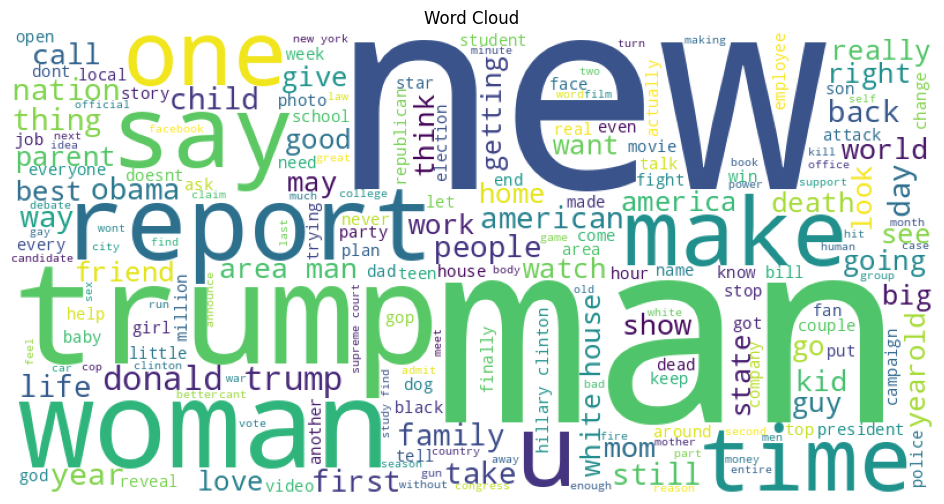

In [8]:
all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Word Cloud")

plt.show()

##9. Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['is_sarcastic'],
    test_size=0.2,
    random_state=42
)

print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))

Training Size: 22895
Testing Size: 5724


##10. Tokenization

In [10]:
MAX_WORDS = 10000

tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

##11. Padding

In [11]:
lengths = [len(x) for x in X_train_seq]

max_len = int(np.percentile(lengths, 95))

print("Max Length:", max_len)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

Max Length: 10


##12. Model 1 — Simple RNN

In [12]:
vocab_size = MAX_WORDS

embedding_dim = 128

rnn_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    SimpleRNN(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Build model manually
rnn_model.build(input_shape=(None, max_len))

# Show summary
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,465 (4.94 MB)

 Trainable params: 1,294,465 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

##13. Compile RNN Model

In [13]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##14. Train RNN Model

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7391 - loss: 0.5158 - val_accuracy: 0.7764 - val_loss: 0.4666
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8925 - loss: 0.2668 - val_accuracy: 0.7936 - val_loss: 0.4881
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9588 - loss: 0.1160 - val_accuracy: 0.7724 - val_loss: 0.6612
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9817 - loss: 0.0558 - val_accuracy: 0.7685 - val_loss: 0.9121


##15. Model 2 — LSTM

In [15]:
lstm_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

lstm_model.build(input_shape=(None, max_len))

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,521 (5.08 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

##16. Compile LSTM Model

In [16]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##17. Train LSTM Model

In [17]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7370 - loss: 0.5110 - val_accuracy: 0.7890 - val_loss: 0.4418
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8627 - loss: 0.3220 - val_accuracy: 0.7853 - val_loss: 0.4679
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9089 - loss: 0.2220 - val_accuracy: 0.7890 - val_loss: 0.5513
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.9417 - loss: 0.1421 - val_accuracy: 0.7759 - val_loss: 0.7376


##18. Install Word2Vec Requirements

In [18]:
!pip install numpy

##19. Import Gensim

In [19]:
!pip install gensim
import gensim.downloader as api

##20. Load Pretrained Word2Vec

In [20]:
embedding_model = api.load('glove-wiki-gigaword-50')

##21. Create Embedding Matrix

In [25]:
# Use the ORIGINAL tokenizer from Section 10 (already fitted on real data)
word_index = tokenizer.word_index

# Use the same vocab size and embedding dim as before
vocab_size = MAX_WORDS       # 10000
embedding_dim = 50           # must match GloVe dimension (glove-wiki-gigaword-50 = 50)

# Build embedding matrix using the real GloVe model loaded in Section 20
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)  # Should be (10000, 50)

Embedding matrix shape: (10000, 50)


##22. Model 3 — Word2Vec + LSTM

In [26]:
word2vec_model = Sequential([
    Embedding(
        input_dim=vocab_size,       # 10000 ✅
        output_dim=embedding_dim,   # 50 ✅
        weights=[embedding_matrix], # real GloVe weights ✅
        trainable=False
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

word2vec_model.build(input_shape=(None, max_len))
word2vec_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 10, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,553 (2.03 MB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 500,000 (1.91 MB)




##23. Compile Word2Vec Model

In [27]:
word2vec_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##24. Train Word2Vec Model

In [28]:
history_word2vec = word2vec_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5778 - loss: 0.6637 - val_accuracy: 0.5741 - val_loss: 0.6624
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5870 - loss: 0.6563 - val_accuracy: 0.5748 - val_loss: 0.6593
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5878 - loss: 0.6554 - val_accuracy: 0.5722 - val_loss: 0.6637


##25. Compare Validation Accuracy

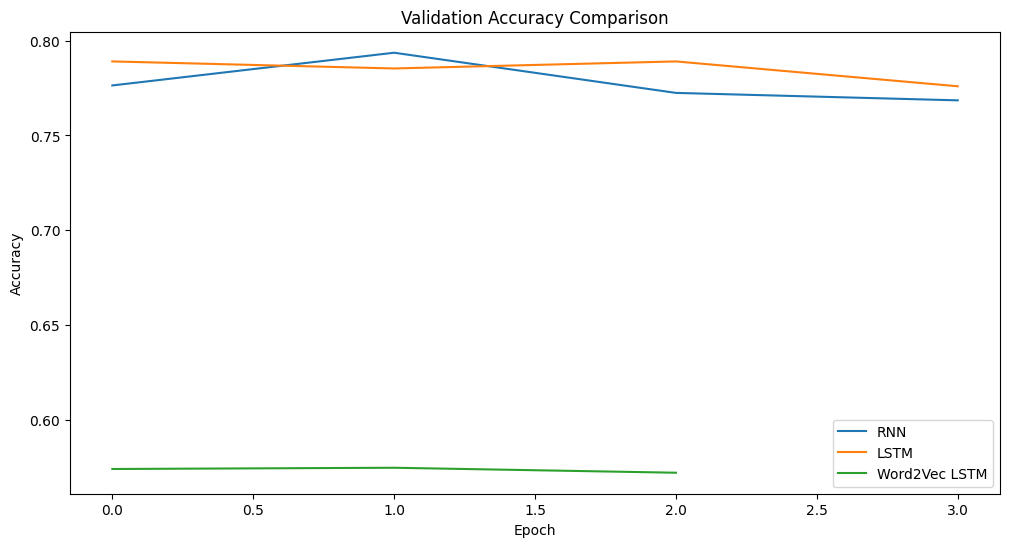

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    history_rnn.history['val_accuracy'],
    label='RNN'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM'
)

plt.plot(
    history_word2vec.history['val_accuracy'],
    label='Word2Vec LSTM'
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

##26. Evaluate Models

In [30]:
rnn_loss, rnn_acc = rnn_model.evaluate(
    X_test_pad,
    y_test
)

lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_pad,
    y_test
)

w2v_loss, w2v_acc = word2vec_model.evaluate(
    X_test_pad,
    y_test
)

print("RNN Accuracy:", rnn_acc)

print("LSTM Accuracy:", lstm_acc)

print("Word2Vec Accuracy:", w2v_acc)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7804 - loss: 0.4609
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7874 - loss: 0.4433
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5830 - loss: 0.6567
RNN Accuracy: 0.7803983092308044
LSTM Accuracy: 0.787386417388916
Word2Vec Accuracy: 0.5829839110374451


##27. Predictions

In [31]:
predictions = word2vec_model.predict(X_test_pad)

y_pred = (predictions > 0.5).astype(int)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


##28. Confusion Matrix

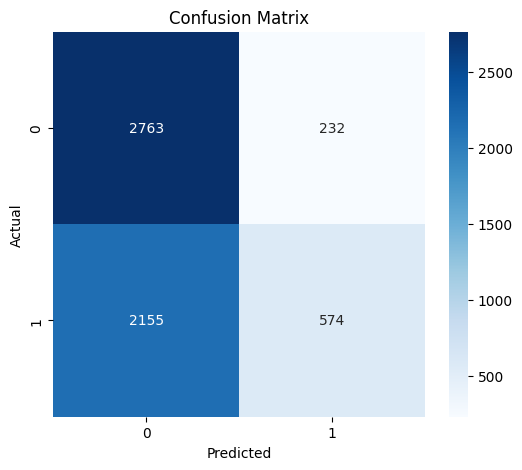

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

##29. Classification Report

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.92      0.70      2995
           1       0.71      0.21      0.32      2729

    accuracy                           0.58      5724
   macro avg       0.64      0.57      0.51      5724
weighted avg       0.63      0.58      0.52      5724



##30. Error Analysis

In [34]:
misclassified = []

for i in range(len(y_test)):

    if y_test.iloc[i] != y_pred[i]:

        misclassified.append(i)

print("Total Misclassified:", len(misclassified))

Total Misclassified: 2387


##31. Show Wrong Predictions

In [35]:
for i in misclassified[:3]:

    print("Headline:", X_test.iloc[i])

    print("Actual:", y_test.iloc[i])

    print("Predicted:", y_pred[i][0])

    print()

Headline: drone place fresh kill step white house
Actual: 1
Predicted: 0

Headline: report majority instance people getting life back track occur immediately visit buffalo wild wing
Actual: 1
Predicted: 0

Headline: sole remaining lung filled rich satisfying flavor
Actual: 1
Predicted: 0



##32. Install Gradio

In [36]:
!pip install gradio

##33. Import Gradio

In [37]:
import gradio as gr

##34. Prediction Function

In [38]:
def predict_sarcasm(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    pad = pad_sequences(
        seq,
        maxlen=max_len,
        padding='post'
    )

    pred = word2vec_model.predict(pad)[0][0]

    if pred > 0.5:
        return "Sarcastic"

    else:
        return "Not Sarcastic"

##35. Create GUI

In [39]:
def predict_sarcasm(text):
    try:
        # 1. Use the cleaning function from Page 3
        cleaned = clean_text(text)

        # 2. Use the ORIGINAL tokenizer from Page 4
        seq = tokenizer.texts_to_sequences([cleaned])

        # 3. Use the max_len from Page 4
        pad = pad_sequences(seq, maxlen=max_len, padding='post')

        # 4. Predict using your Word2Vec model
        pred = word2vec_model.predict(pad)[0][0]

        return f"Prediction: {'Sarcastic' if pred > 0.5 else 'Genuine'} (Confidence: {pred:.2f})"
    except Exception as e:
        return f"Error: {str(e)}. Make sure you ran all previous cells!"

# Create and Launch
interface = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(lines=2, placeholder="Enter a headline here..."),
    outputs="text",
    title="Sarcasm Detector",
    description="Enter a news headline to see if the AI thinks it is sarcastic."
)
interface.launch(debug=True) # debug=True helps see errors directly in Colab

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://23d3f9edec6d132bb2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://23d3f9edec6d132bb2.gradio.live
